In [1]:
# ==========================================================
# Notebook 01: Building a Search Corpus
# ==========================================================

import pandas as pd
import numpy as np

from pathlib import Path

In [2]:
documents = [
    {
        "doc_id": 1,
        "title": "Artificial Intelligence for Beginners",
        "category": "AI",
        "text": "Artificial Intelligence is the simulation of human intelligence by machines.",
    },
    {
        "doc_id": 2,
        "title": "Machine Learning Basics",
        "category": "ML",
        "text": "Machine Learning is a subset of Artificial Intelligence that learns from data.",
    },
    {
        "doc_id": 3,
        "title": "Deep Learning Introduction",
        "category": "DL",
        "text": "Deep Learning uses neural networks with multiple hidden layers.",
    },
    {
        "doc_id": 4,
        "title": "Natural Language Processing",
        "category": "NLP",
        "text": "Natural Language Processing helps computers understand human language.",
    },
    {
        "doc_id": 5,
        "title": "Python Programming",
        "category": "Programming",
        "text": "Python is one of the most popular programming languages for AI.",
    },
]

In [3]:
documents

[{'doc_id': 1,
  'title': 'Artificial Intelligence for Beginners',
  'category': 'AI',
  'text': 'Artificial Intelligence is the simulation of human intelligence by machines.'},
 {'doc_id': 2,
  'title': 'Machine Learning Basics',
  'category': 'ML',
  'text': 'Machine Learning is a subset of Artificial Intelligence that learns from data.'},
 {'doc_id': 3,
  'title': 'Deep Learning Introduction',
  'category': 'DL',
  'text': 'Deep Learning uses neural networks with multiple hidden layers.'},
 {'doc_id': 4,
  'title': 'Natural Language Processing',
  'category': 'NLP',
  'text': 'Natural Language Processing helps computers understand human language.'},
 {'doc_id': 5,
  'title': 'Python Programming',
  'category': 'Programming',
  'text': 'Python is one of the most popular programming languages for AI.'}]

In [4]:
corpus_df = pd.DataFrame(documents)

corpus_df

,doc_id,title,category,text
0,1,Artificial Intelligence for Beginners,AI,Artificial Intelligence is the simulation of h...
1,2,Machine Learning Basics,ML,Machine Learning is a subset of Artificial Int...
2,3,Deep Learning Introduction,DL,Deep Learning uses neural networks with multip...
3,4,Natural Language Processing,NLP,Natural Language Processing helps computers un...
4,5,Python Programming,Programming,Python is one of the most popular programming ...


In [5]:
print("Total Documents:", len(corpus_df))

Total Documents: 5


In [6]:
corpus_df["category"].value_counts()

category
AI             1
ML             1
DL             1
NLP            1
Programming    1
Name: count, dtype: int64

In [7]:
corpus_df["char_length"] = corpus_df["text"].apply(len)

corpus_df[["title", "char_length"]]

,title,char_length
0,Artificial Intelligence for Beginners,76
1,Machine Learning Basics,78
2,Deep Learning Introduction,63
3,Natural Language Processing,70
4,Python Programming,63


In [8]:
corpus_df["word_count"] = corpus_df["text"].apply(lambda x: len(x.split()))

corpus_df[["title", "word_count"]]

,title,word_count
0,Artificial Intelligence for Beginners,10
1,Machine Learning Basics,12
2,Deep Learning Introduction,9
3,Natural Language Processing,8
4,Python Programming,11


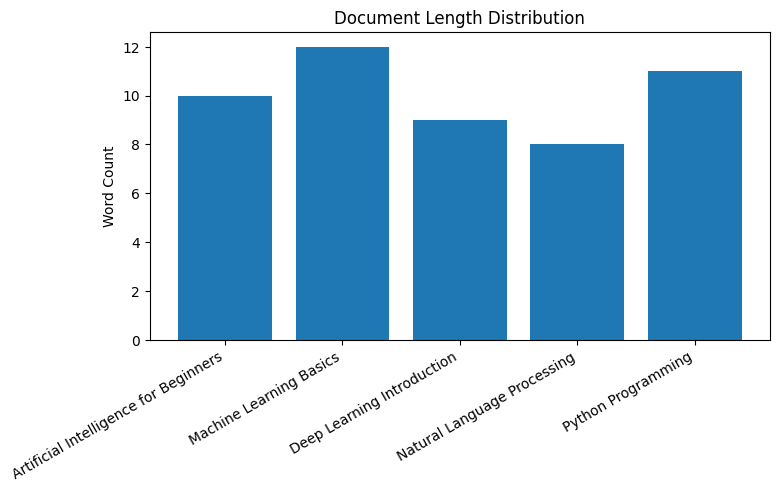

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))

plt.bar(corpus_df["title"], corpus_df["word_count"])

plt.xticks(rotation=30, ha="right")

plt.ylabel("Word Count")

plt.title("Document Length Distribution")

plt.show()

In [10]:
print("Missing Values:\n")

print(corpus_df.isnull().sum())

Missing Values:

doc_id         0
title          0
category       0
text           0
char_length    0
word_count     0
dtype: int64


In [11]:
duplicates = corpus_df.duplicated(subset=["text"]).sum()

print("Duplicate Documents:", duplicates)

Duplicate Documents: 0


In [12]:
empty_docs = corpus_df["text"].str.strip().eq("").sum()

print("Empty Documents:", empty_docs)

Empty Documents: 0


In [13]:
corpus_df["source"] = "internal_knowledge_base"

corpus_df["language"] = "en"

corpus_df["version"] = "v1"

corpus_df[["doc_id", "title", "category", "source", "language", "version"]]

,doc_id,title,category,source,language,version
0,1,Artificial Intelligence for Beginners,AI,internal_knowledge_base,en,v1
1,2,Machine Learning Basics,ML,internal_knowledge_base,en,v1
2,3,Deep Learning Introduction,DL,internal_knowledge_base,en,v1
3,4,Natural Language Processing,NLP,internal_knowledge_base,en,v1
4,5,Python Programming,Programming,internal_knowledge_base,en,v1


In [14]:
output_path = Path("data")

output_path.mkdir(exist_ok=True)

corpus_df.to_csv(output_path / "search_corpus.csv", index=False)

print("Corpus saved successfully!")

Corpus saved successfully!


In [15]:
loaded_df = pd.read_csv("data/search_corpus.csv")

loaded_df.head()

,doc_id,title,category,text,char_length,word_count,source,language,version
0,1,Artificial Intelligence for Beginners,AI,Artificial Intelligence is the simulation of h...,76,10,internal_knowledge_base,en,v1
1,2,Machine Learning Basics,ML,Machine Learning is a subset of Artificial Int...,78,12,internal_knowledge_base,en,v1
2,3,Deep Learning Introduction,DL,Deep Learning uses neural networks with multip...,63,9,internal_knowledge_base,en,v1
3,4,Natural Language Processing,NLP,Natural Language Processing helps computers un...,70,8,internal_knowledge_base,en,v1
4,5,Python Programming,Programming,Python is one of the most popular programming ...,63,11,internal_knowledge_base,en,v1


In [16]:
def load_search_corpus(file_path):
    """
    Load a search corpus from CSV.
    """

    df = pd.read_csv(file_path)

    print(f"Loaded {len(df)} documents.")

    return df

In [17]:
corpus = load_search_corpus("data/search_corpus.csv")

corpus.head()

Loaded 5 documents.


,doc_id,title,category,text,char_length,word_count,source,language,version
0,1,Artificial Intelligence for Beginners,AI,Artificial Intelligence is the simulation of h...,76,10,internal_knowledge_base,en,v1
1,2,Machine Learning Basics,ML,Machine Learning is a subset of Artificial Int...,78,12,internal_knowledge_base,en,v1
2,3,Deep Learning Introduction,DL,Deep Learning uses neural networks with multip...,63,9,internal_knowledge_base,en,v1
3,4,Natural Language Processing,NLP,Natural Language Processing helps computers un...,70,8,internal_knowledge_base,en,v1
4,5,Python Programming,Programming,Python is one of the most popular programming ...,63,11,internal_knowledge_base,en,v1
